# CardioModel Shift

## Cross-Population Heart Disease Classification Audit

This notebook investigates whether heart-disease classification models trained on one patient cohort maintain their performance when evaluated on a different cohort.

## 1. Environment setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")

print(f"Working directory: {Path.cwd()}")
print("Imports successful")

Working directory: d:\Projects\CardioModel Project\cardiomodel-shift\notebooks
Imports successful


In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "uci_heart_disease"

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Data directory exists: {DATA_DIR.exists()}")

Project root: d:\Projects\CardioModel Project\cardiomodel-shift
Data directory: d:\Projects\CardioModel Project\cardiomodel-shift\data\raw\uci_heart_disease
Data directory exists: True


## 2. Load the source cohorts

The processed Cleveland and Hungarian cohorts use the standard 14-variable UCI Heart Disease structure. Missing values are encoded as question marks in the source files and are converted to Python missing values during import.

In [3]:
COLUMN_NAMES = [
    "age",
    "sex",
    "chest_pain_type",
    "resting_blood_pressure",
    "serum_cholesterol",
    "fasting_blood_sugar",
    "resting_ecg",
    "max_heart_rate",
    "exercise_induced_angina",
    "st_depression",
    "st_slope",
    "major_vessels",
    "thalassemia",
    "disease_severity",
]

cleveland = pd.read_csv(
    DATA_DIR / "processed.cleveland.data",
    header=None,
    names=COLUMN_NAMES,
    na_values="?",
)

hungary = pd.read_csv(
    DATA_DIR / "processed.hungarian.data",
    header=None,
    names=COLUMN_NAMES,
    na_values="?",
)

cleveland["cohort"] = "Cleveland"
hungary["cohort"] = "Hungary"

print(f"Cleveland shape: {cleveland.shape}")
print(f"Hungary shape: {hungary.shape}")

display(cleveland.head())
display(hungary.head())

Cleveland shape: (303, 15)
Hungary shape: (294, 15)


,age,sex,chest_pain_type,resting_blood_pressure,serum_cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,major_vessels,thalassemia,disease_severity,cohort
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,Cleveland
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,Cleveland
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,Cleveland
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,Cleveland
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,Cleveland


,age,sex,chest_pain_type,resting_blood_pressure,serum_cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,major_vessels,thalassemia,disease_severity,cohort
0,28,1,2,130.0,132.0,0.0,2.0,185.0,0.0,0.0,NaN,NaN,NaN,0,Hungary
1,29,1,2,120.0,243.0,0.0,0.0,160.0,0.0,0.0,NaN,NaN,NaN,0,Hungary
2,29,1,2,140.0,NaN,0.0,0.0,170.0,0.0,0.0,NaN,NaN,NaN,0,Hungary
3,30,0,1,170.0,237.0,0.0,1.0,170.0,0.0,0.0,NaN,NaN,6.0,0,Hungary
4,31,0,2,100.0,219.0,0.0,1.0,150.0,0.0,0.0,NaN,NaN,NaN,0,Hungary


## 3. Initial data-quality audit

Before preprocessing or modelling, the cohorts are checked for missing values, duplicate records and differences in their recorded disease outcomes.

In [4]:
heart_data = pd.concat([cleveland, hungary], ignore_index=True)

missing_summary = pd.DataFrame(
    {
        "Cleveland": cleveland[COLUMN_NAMES].isna().sum(),
        "Hungary": hungary[COLUMN_NAMES].isna().sum(),
    }
)
missing_summary["Total"] = missing_summary.sum(axis=1)

print(f"Combined patient records: {len(heart_data)}")
print(
    "Cleveland duplicate rows:",
    cleveland.duplicated(subset=COLUMN_NAMES).sum(),
)
print(
    "Hungary duplicate rows:",
    hungary.duplicated(subset=COLUMN_NAMES).sum(),
)

print("\nMissing values:")
display(missing_summary.loc[missing_summary["Total"] > 0])

print("\nDisease-severity values by cohort:")
display(
    pd.crosstab(
        heart_data["cohort"],
        heart_data["disease_severity"],
        dropna=False,
    )
)

Combined patient records: 597
Cleveland duplicate rows: 0
Hungary duplicate rows: 1

Missing values:


,Cleveland,Hungary,Total
resting_blood_pressure,0,1,1
serum_cholesterol,0,23,23
fasting_blood_sugar,0,8,8
resting_ecg,0,1,1
max_heart_rate,0,1,1
exercise_induced_angina,0,1,1
st_slope,0,190,190
major_vessels,4,291,295
thalassemia,2,266,268



Disease-severity values by cohort:


disease_severity,0,1,2,3,4
cohort,,,,,
Cleveland,164,55,36,35,13
Hungary,188,106,0,0,0


### Binary outcome definition

The source cohorts encode the outcome at different levels of detail. Cleveland records values from 0 to 4, whereas Hungary records only 0 and 1. Following the UCI dataset definition, 0 is treated as no recorded heart disease and every value greater than 0 is treated as recorded heart disease.

The resulting model classifies recorded disease presence. It does not predict future cardiovascular risk or disease severity.

In [5]:
heart_data["heart_disease"] = (
    heart_data["disease_severity"] > 0
).astype(int)

outcome_summary = (
    heart_data.groupby("cohort")
    .agg(
        patient_count=("heart_disease", "size"),
        disease_cases=("heart_disease", "sum"),
        disease_prevalence=("heart_disease", "mean"),
    )
)

outcome_summary["disease_prevalence"] = (
    outcome_summary["disease_prevalence"] * 100
).round(1)

display(outcome_summary)

,patient_count,disease_cases,disease_prevalence
cohort,,,
Cleveland,303,139,45.9
Hungary,294,106,36.1


### Harmonised feature set

The cross-cohort model uses variables that are meaningfully available in both cohorts. `st_slope`, `major_vessels` and `thalassemia` are excluded because their missingness in the Hungarian cohort is too extensive for a fair comparison.

The remaining missing values will be handled inside the modelling pipeline so that replacement values are learned only from training data.

In [6]:
NUMERIC_FEATURES = [
    "age",
    "resting_blood_pressure",
    "serum_cholesterol",
    "max_heart_rate",
    "st_depression",
]

CATEGORICAL_FEATURES = [
    "sex",
    "chest_pain_type",
    "fasting_blood_sugar",
    "resting_ecg",
    "exercise_induced_angina",
]

MODEL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

feature_audit = pd.DataFrame(
    {
        "feature_type": [
            "Numeric" if column in NUMERIC_FEATURES else "Categorical"
            for column in MODEL_FEATURES
        ],
        "cleveland_missing": cleveland[MODEL_FEATURES].isna().sum(),
        "hungary_missing": hungary[MODEL_FEATURES].isna().sum(),
        "cleveland_unique": cleveland[MODEL_FEATURES].nunique(),
        "hungary_unique": hungary[MODEL_FEATURES].nunique(),
    }
)

display(feature_audit)

,feature_type,cleveland_missing,hungary_missing,cleveland_unique,hungary_unique
age,Numeric,0,0,41,38
resting_blood_pressure,Numeric,0,1,50,31
serum_cholesterol,Numeric,0,23,152,153
max_heart_rate,Numeric,0,1,91,71
st_depression,Numeric,0,0,40,10
sex,Categorical,0,0,2,2
chest_pain_type,Categorical,0,0,4,4
fasting_blood_sugar,Categorical,0,8,2,2
resting_ecg,Categorical,0,1,3,3
exercise_induced_angina,Categorical,0,1,2,2


The selected features have complete coverage in Cleveland. Hungary contains 35 missing cells across six selected variables, with serum cholesterol accounting for most of them. These gaps are limited enough to handle through training-data imputation.

All selected categorical variables contain the same number of observed categories in both cohorts. However, ST depression has substantially fewer unique values in Hungary, suggesting a possible difference in measurement granularity.

One exact feature-and-outcome match was identified in Hungary but retained because the source contains no patient identifier with which to establish that it is an accidental duplicate.

In [7]:
numeric_shift_rows = []

for feature in NUMERIC_FEATURES:
    cleveland_values = cleveland[feature].dropna()
    hungary_values = hungary[feature].dropna()

    pooled_sd = np.sqrt(
        (cleveland_values.var() + hungary_values.var()) / 2
    )

    standardized_difference = (
        cleveland_values.mean() - hungary_values.mean()
    ) / pooled_sd

    numeric_shift_rows.append(
        {
            "feature": feature,
            "cleveland_mean": cleveland_values.mean(),
            "hungary_mean": hungary_values.mean(),
            "standardized_difference": standardized_difference,
            "absolute_difference": abs(standardized_difference),
        }
    )

numeric_shift = (
    pd.DataFrame(numeric_shift_rows)
    .set_index("feature")
    .sort_values("absolute_difference", ascending=False)
    .round(2)
)

display(numeric_shift)

,cleveland_mean,hungary_mean,standardized_difference,absolute_difference
feature,,,,
age,54.44,47.83,0.78,0.78
max_heart_rate,149.61,139.13,0.45,0.45
st_depression,1.04,0.59,0.44,0.44
serum_cholesterol,246.69,250.85,-0.07,0.07
resting_blood_pressure,131.69,132.58,-0.05,0.05


Age showed the largest numeric cohort difference: Cleveland patients were approximately 6.6 years older on average, producing a standardized difference of 0.78. Maximum heart rate and ST depression showed moderate differences, while mean serum cholesterol and resting blood pressure were comparatively similar.

These are descriptive population differences. They do not establish why the cohorts differ or whether cohort membership caused the observed values.

In [8]:
category_value_audit = []

for feature in CATEGORICAL_FEATURES:
    category_value_audit.append(
        {
            "feature": feature,
            "cleveland_values": sorted(
                cleveland[feature].dropna().unique().tolist()
            ),
            "hungary_values": sorted(
                hungary[feature].dropna().unique().tolist()
            ),
        }
    )

category_value_audit = pd.DataFrame(category_value_audit)
display(category_value_audit)

,feature,cleveland_values,hungary_values
0,sex,"[0.0, 1.0]","[0, 1]"
1,chest_pain_type,"[1.0, 2.0, 3.0, 4.0]","[1, 2, 3, 4]"
2,fasting_blood_sugar,"[0.0, 1.0]","[0.0, 1.0]"
3,resting_ecg,"[0.0, 1.0, 2.0]","[0.0, 1.0, 2.0]"
4,exercise_induced_angina,"[0.0, 1.0]","[0.0, 1.0]"


### Categorical feature distributions

The following charts compare the percentage distribution of each categorical feature across the Cleveland and Hungarian cohorts. Missing values are shown explicitly rather than silently removed.

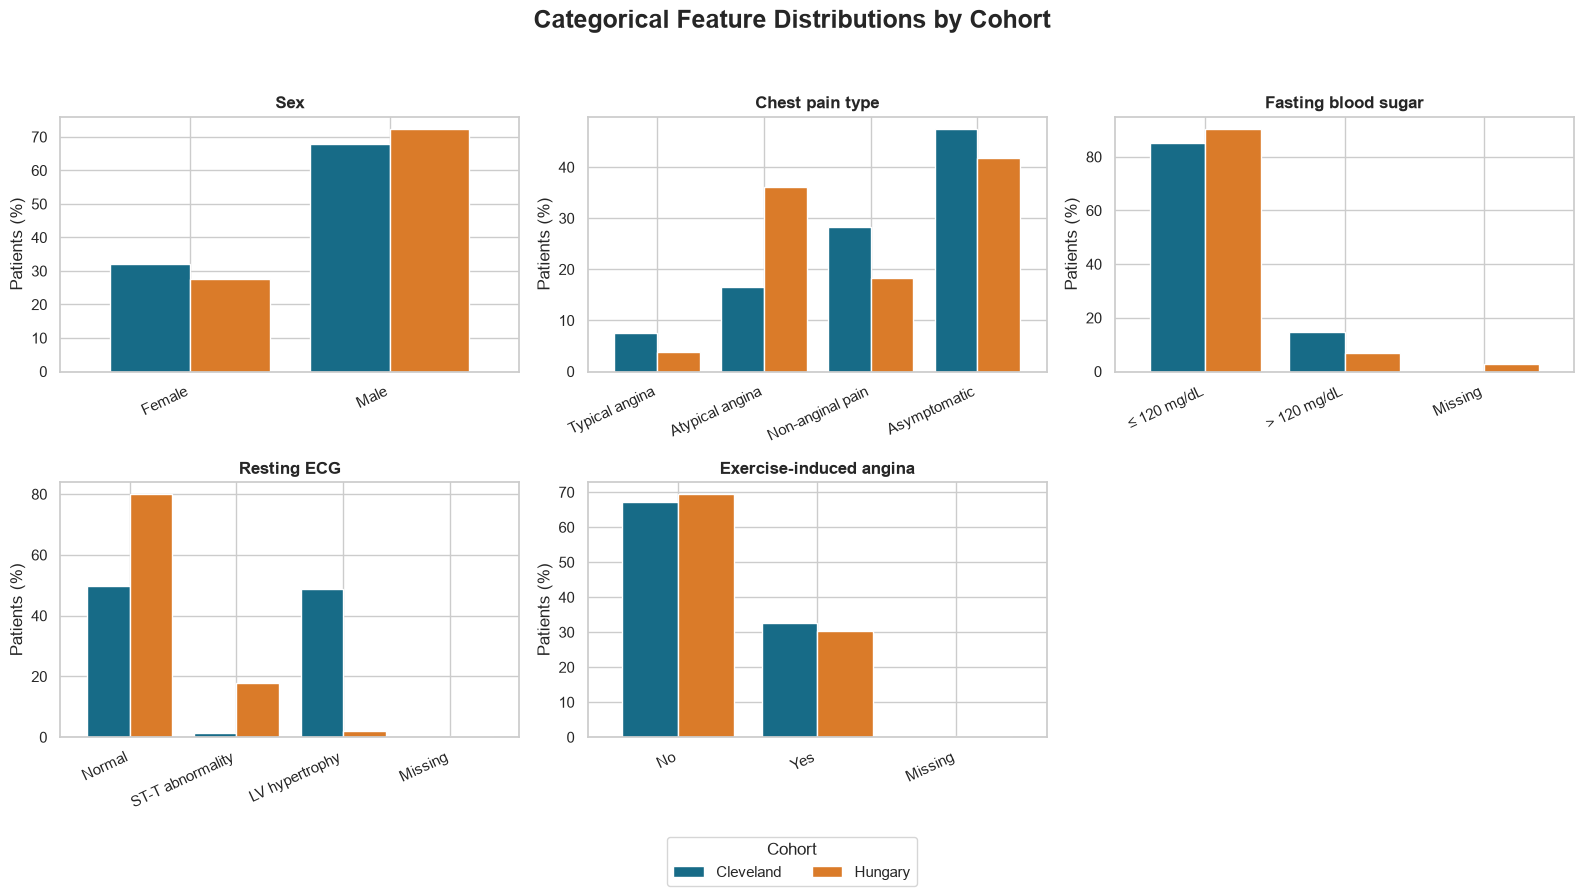

Figure saved to: d:\Projects\CardioModel Project\cardiomodel-shift\outputs\figures\categorical_feature_distributions.png


In [9]:
CATEGORY_LABELS = {
    "sex": {
        0: "Female",
        1: "Male",
    },
    "chest_pain_type": {
        1: "Typical angina",
        2: "Atypical angina",
        3: "Non-anginal pain",
        4: "Asymptomatic",
    },
    "fasting_blood_sugar": {
        0: "≤ 120 mg/dL",
        1: "> 120 mg/dL",
    },
    "resting_ecg": {
        0: "Normal",
        1: "ST-T abnormality",
        2: "LV hypertrophy",
    },
    "exercise_induced_angina": {
        0: "No",
        1: "Yes",
    },
}

FEATURE_TITLES = {
    "sex": "Sex",
    "chest_pain_type": "Chest pain type",
    "fasting_blood_sugar": "Fasting blood sugar",
    "resting_ecg": "Resting ECG",
    "exercise_induced_angina": "Exercise-induced angina",
}

FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

legend_handles = None
legend_labels = None

for ax, feature in zip(axes, CATEGORICAL_FEATURES):
    plot_data = heart_data[["cohort", feature]].copy()

    plot_data["category"] = (
        plot_data[feature]
        .map(CATEGORY_LABELS[feature])
        .fillna("Missing")
    )

    category_order = list(CATEGORY_LABELS[feature].values())

    if plot_data["category"].eq("Missing").any():
        category_order.append("Missing")

    proportions = (
        pd.crosstab(
            plot_data["category"],
            plot_data["cohort"],
            normalize="columns",
        )
        .reindex(
            index=category_order,
            columns=["Cleveland", "Hungary"],
            fill_value=0,
        )
        .mul(100)
    )

    proportions.plot(
        kind="bar",
        ax=ax,
        color=["#176B87", "#DA7B29"],
        width=0.8,
    )

    ax.set_title(FEATURE_TITLES[feature], fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Patients (%)")
    ax.tick_params(axis="x", rotation=25)

    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")

    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    ax.get_legend().remove()

axes[-1].axis("off")

fig.suptitle(
    "Categorical Feature Distributions by Cohort",
    fontsize=18,
    fontweight="bold",
)

fig.legend(
    legend_handles,
    legend_labels,
    title="Cohort",
    loc="lower center",
    ncol=2,
)

fig.tight_layout(rect=[0, 0.07, 1, 0.95])

figure_path = FIGURE_DIR / "categorical_feature_distributions.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {figure_path}")

Resting ECG showed the largest categorical distribution difference. Left ventricular hypertrophy was frequently recorded in Cleveland but was almost absent in Hungary, where normal ECG results predominated. Chest-pain categories also differed, particularly the frequency of atypical angina and non-anginal pain.

Sex and exercise-induced angina were more similarly distributed. The source data cannot distinguish whether these differences arose from patient populations, clinical measurement, coding practices or other collection procedures.

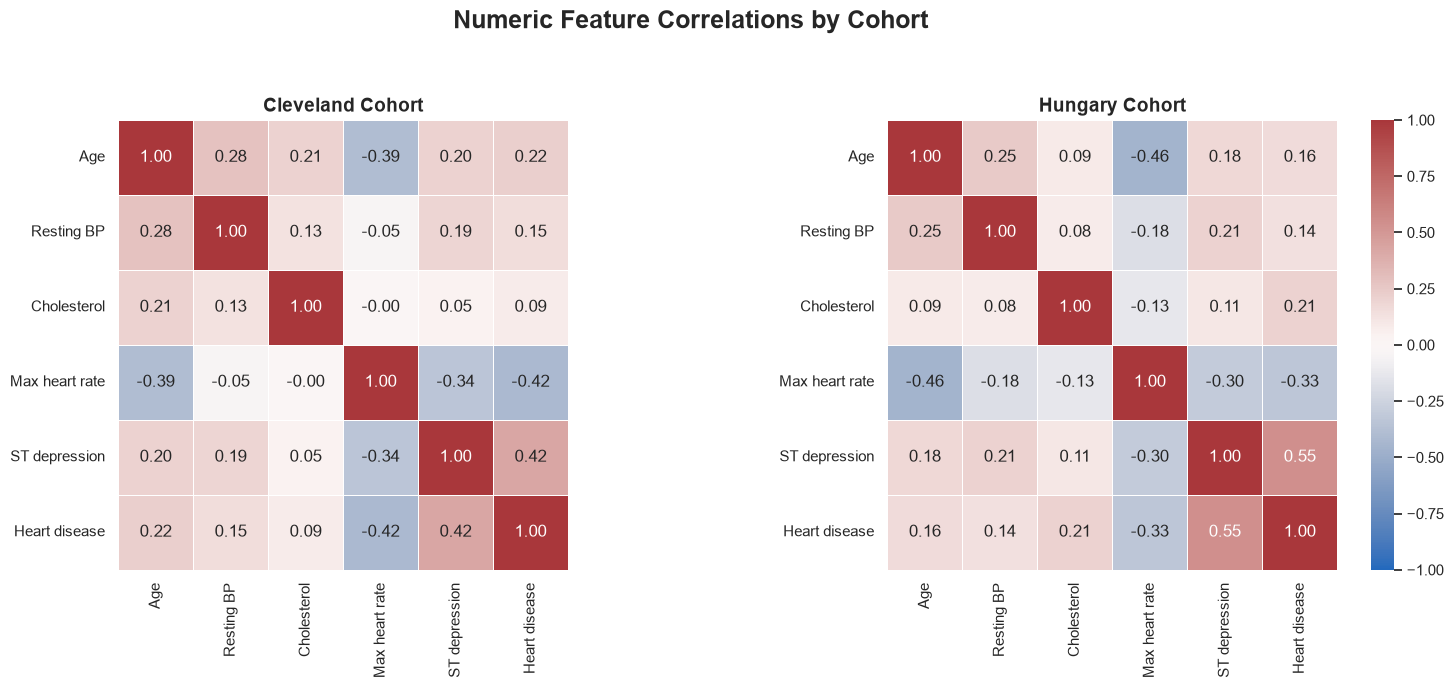

Figure saved to: d:\Projects\CardioModel Project\cardiomodel-shift\outputs\figures\numeric_correlations_by_cohort.png


In [10]:
CORRELATION_LABELS = {
    "age": "Age",
    "resting_blood_pressure": "Resting BP",
    "serum_cholesterol": "Cholesterol",
    "max_heart_rate": "Max heart rate",
    "st_depression": "ST depression",
    "heart_disease": "Heart disease",
}

correlation_features = NUMERIC_FEATURES + ["heart_disease"]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for index, cohort_name in enumerate(["Cleveland", "Hungary"]):
    cohort_data = heart_data.loc[
        heart_data["cohort"] == cohort_name,
        correlation_features,
    ].rename(columns=CORRELATION_LABELS)

    correlation_matrix = cohort_data.corr()

    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt=".2f",
        cmap="vlag",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        ax=axes[index],
        cbar=index == 1,
    )

    axes[index].set_title(
        f"{cohort_name} Cohort",
        fontsize=14,
        fontweight="bold",
    )

fig.suptitle(
    "Numeric Feature Correlations by Cohort",
    fontsize=18,
    fontweight="bold",
)

fig.tight_layout(rect=[0, 0, 1, 0.94])

correlation_path = FIGURE_DIR / "numeric_correlations_by_cohort.png"
fig.savefig(correlation_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"Figure saved to: {correlation_path}")

The direction of the main numeric relationships was broadly consistent across cohorts. Recorded heart disease was positively correlated with ST depression and negatively correlated with maximum heart rate in both populations.

However, the strength of these relationships differed. ST depression had a stronger association with disease in Hungary, while maximum heart rate had a stronger negative association in Cleveland. Cholesterol also showed a stronger association with disease in Hungary.

These correlations are unadjusted descriptive relationships. They do not measure causation or show how the variables will behave when considered together by a model.